c:\Users\sam\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


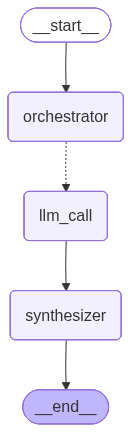

## Introduction to LLM Scaling Laws

Large language models (LLMs) exhibit distinctive scaling laws that dictate how their performance improves as we increase various factors such as dataset size, model parameters, and computational resources. These laws suggest that there are predictable patterns in model performance that can be leveraged to enhance future model development.

### Fundamental Principles

1. **Data Scaling**: As the size of the training dataset increases, LLMs tend to achieve better performance. This improvement can often be characterized by power-law relationships, where performance gains become less pronounced after a certain threshold of data volume is reached. Studies indicate that more extensive and diverse datasets allow models to generalize better, reducing overfitting and improving their ability to understand nuanced language patterns.

2. **Model Size Scaling**: Increasing the number of parameters in a language model typically results in enhanced capabilities. Research has shown that larger models can capture more complex patterns in data, leading to improvements in tasks such as translation, summarization, and question answering. However, diminishing returns are observed at extreme sizes, where additional parameters may yield minimal performance gains compared to the computational costs incurred.

3. **Compute Scaling**: More compute resources facilitate the training of larger models on more extensive datasets, directly impacting performance. Studies have demonstrated that training iterations and the efficiency of optimization algorithms play crucial roles in this aspect. Enhanced computational capabilities allow for more thorough training processes, enabling models to converge to better solutions.

### Key Research Findings

Numerous studies have documented the scaling laws of LLMs, establishing a foundation for predicting performance based on the ratio of data size, model size, and computational resources:

- **OpenAI's GPT series** has shown consistent improvements in language understanding and generation as model sizes have doubled, highlighting the trend towards larger architectures leading to enhanced capabilities.
  
- **Google's T5 model** demonstrated how task performance could be improved dramatically with increases in both data volume and model parameters, reinforcing the synergistic relationship between these two factors.

- **Scaling laws in the EleutherAI's GPT-Neo** models emphasized the importance of fine-tuning on diverse datasets to achieve optimal performance, showcasing that the benefits of scaling are not solely dependent on model size.

### Implications for Future Development

Understanding the scaling laws of LLMs has significant implications for future research and development:
- **Resource Allocation**: As organizations consider investments in LLM training, insights into these scaling laws can guide decisions on data collection, model architecture, and computational infrastructure.
  
- **Model Optimization**: Developers can prioritize strategies that maximize performance gains relative to resource expenditure, optimizing the trade-offs between model size, training time, and dataset breadth.

- **Sustainability Considerations**: Awareness of the scaling laws encourages a more sustainable approach to LLM development, prompting researchers to explore methods that minimize resource consumption while maximizing output efficiency.

In summary, the scaling laws of large language models illustrate the intricate relationships between model size, data, and compute resources, providing a roadmap for future advancements in the field of natural language processing.

---

## Practical Implications of Scaling Laws

Scaling laws have profound implications for the development and deployment of large language models (LLMs). Understanding these laws allows practitioners to make informed decisions on various aspects of model design and resource management. Here, we explore several key applications and considerations tied to the scaling of LLMs.

### Resource Allocation

One of the primary applications of scaling laws is in resource allocation. By analyzing how performance scales with model size, data volume, and training duration, developers can prioritize investments in areas that yield the highest returns. For example, if a model's performance improves significantly with increased parameters but only marginally with additional training data, efforts can be concentrated on expanding the model's architecture rather than amassing more data.

### Model Architecture

Scaling laws inform decisions regarding model architecture. Insights gained from empirical studies indicate that larger models tend to generalize better and exhibit improved performance on downstream tasks. This understanding drives researchers to explore architectures that can efficiently utilize increased computational resources while maintaining manageable training times. Adopting modular architectures or optimizing hyperparameters can lead to better scaling without linear increases in cost.

### Training Strategies

Training strategies can also benefit from scaling law insights. For instance, understanding the relationship between the number of training epochs and model performance can help in determining optimal training times. Practitioners can adopt adaptive training techniques that dynamically adjust based on performance metrics, thus avoiding excessive resource expenditure on diminishing returns after a certain point.

### Trade-offs in Scaling

While scaling can lead to substantial performance gains, it is essential to consider the trade-offs involved. Diminishing returns can manifest as performance improvements that do not justify the escalating costs associated with larger models. This includes both financial costs, due to increased computational demands, and environmental costs, as larger models require more energy and resources to train and deploy.

### Environmental Impact

The environmental impact of scaling LLMs is a critical consideration. As models grow in size, their carbon footprint increases correspondingly. Awareness of this issue has led to calls for more sustainable practices in AI development, such as optimizing training algorithms to consume less energy or leveraging more efficient hardware. Researchers are also exploring ways to quantify the environmental impact of model training to promote accountability and encourage greener practices.

### Strategies for Efficient Resource Utilization

To maximize model performance while minimizing costs and environmental impact, several strategies can be employed:
- **Model Distillation**: Producing smaller, more efficient models that retain the performance of larger counterparts can reduce resource consumption during deployment.
- **Parameter Sharing**: Techniques such as weight sharing among different parts of the model can lead to reduced memory and computational requirements.
- **Dynamic Computation**: Implementing mechanisms to activate only the necessary components of a model based on specific tasks can enhance efficiency.

In conclusion, scaling laws provide critical insights that can guide the responsible development of LLMs. By balancing performance improvements with costs and environmental considerations, practitioners can make strategic decisions that lead to effective and sustainable AI solutions.

In [1]:
# --------------------------------------
# IMPORTS
# --------------------------------------
import os
import operator
from typing import Annotated, List, TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage, HumanMessage
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display, Markdown

# --------------------------------------
# LOAD ENV + INIT LLM
# --------------------------------------
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("❌ Missing OPENAI_API_KEY in .env")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    api_key=api_key
)

# --------------------------------------
# STRUCTURED OUTPUT MODELS
# --------------------------------------
class Section(BaseModel):
    name: str
    description: str

class Sections(BaseModel):
    sections: List[Section]

# Planner LLM for structuring the report
planner = llm.with_structured_output(Sections)

# --------------------------------------
# GRAPH STATE
# --------------------------------------
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_report: str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

# --------------------------------------
# NODES
# --------------------------------------
def orchestrator(state: State):
    """Generate a plan for the report"""
    result = planner.invoke(
        [
            SystemMessage(content="Generate EXACTLY 2 sections for the report."),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"sections": result.sections}


def llm_call(state: WorkerState):
    """Worker writes one section"""
    section_text = llm.invoke(
        [
            SystemMessage(
                content="Write a report section using markdown. No intro/title beyond the section content."
            ),
            HumanMessage(
                content=f"Section name: {state['section'].name}\n"
                        f"Description: {state['section'].description}"
            )
        ]
    )

    return {"completed_sections": [section_text.content]}


def synthesizer(state: State):
    """Combine all sections"""
    combined = "\n\n---\n\n".join(state["completed_sections"])
    return {"final_report": combined}


# Assign a worker to each section using Send()
def assign_workers(state: State):
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# --------------------------------------
# BUILD WORKFLOW
# --------------------------------------
builder = StateGraph(State)

builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestrator")

builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["llm_call"],
)

builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

workflow = builder.compile()

# --------------------------------------
# SHOW GRAPH
# --------------------------------------
display(Image(workflow.get_graph().draw_mermaid_png()))

# --------------------------------------
# RUN WORKFLOW
# --------------------------------------
state = workflow.invoke({"topic": "Create a report on LLM scaling laws"})
Markdown(state["final_report"])
